In [1]:
import math

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
DEVICE = torch.device("mps")

## LSTM

In [17]:
class MyLSTM(nn.Module):

    def __init__(self, input_size: int, hidden_size: int, batch_first: bool):
        super().__init__()

        self.hidden_size = hidden_size
        
        # forget
        self.w_f = nn.Parameter(torch.empty(input_size, hidden_size))
        self.u_f = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b_f = nn.Parameter(torch.empty(1, hidden_size))
        
        # input
        self.w_i = nn.Parameter(torch.empty(input_size, hidden_size))
        self.u_i = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b_i = nn.Parameter(torch.empty(1, hidden_size))
        
        # output
        self.w_o = nn.Parameter(torch.empty(input_size, hidden_size))
        self.u_o = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b_o = nn.Parameter(torch.empty(1, hidden_size))
        
        # cell
        self.w_c = nn.Parameter(torch.empty(input_size, hidden_size))
        self.u_c = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b_c = nn.Parameter(torch.empty(1, hidden_size))

        self._init_params()

    def _init_params(self):
        # not sure, let's try same as RNN?
        a = 1 / math.sqrt(self.hidden_size)
        nn.init.uniform_(self.w_f, -a, a)
        nn.init.uniform_(self.w_i, -a, a)
        nn.init.uniform_(self.w_o, -a, a)
        nn.init.uniform_(self.w_c, -a, a)
        nn.init.uniform_(self.u_f, -a, a)
        nn.init.uniform_(self.u_i, -a, a)
        nn.init.uniform_(self.u_o, -a, a)
        nn.init.uniform_(self.u_c, -a, a)
        nn.init.uniform_(self.b_f, -a, a)
        nn.init.uniform_(self.b_i, -a, a)
        nn.init.uniform_(self.b_o, -a, a)
        nn.init.uniform_(self.b_c, -a, a)

    def forward(self, x: torch.Tensor, h_0: torch.Tensor = None, c_0: torch.Tensor = None) -> tuple:
        if x.dim() == 2:  # assume missing batch
            x = x.unsqueeze(0)  # add batch
        # (B, T, C)
        batch_size, seq_len, _ = x.size()

        if h_0 is None:
            h_0 = torch.zeros(
                batch_size, self.hidden_size, device=x.device, dtype=x.dtype
            )
        if c_0 is None:
            c_0 = torch.zeros(
                batch_size, self.hidden_size, device=x.device, dtype=x.dtype
            )

        out = []
        h_t = h_0
        c_t = c_0
        for t in range(seq_len):
            x_t = x[:, t, :]
            
            f_t = torch.sigmoid(x_t @ self.w_f + h_t @ self.u_f + self.b_f)
            i_t = torch.sigmoid(x_t @ self.w_i + h_t @ self.u_i + self.b_i)
            o_t = torch.sigmoid(x_t @ self.w_o + h_t @ self.u_o + self.b_o)
            c_tilde_t = torch.tanh(x_t @ self.w_c + h_t @ self.u_c + self.b_c)
            
            c_t = f_t * c_t + i_t * c_tilde_t
            h_t = o_t * torch.tanh(c_t)

            out.append(h_t.unsqueeze(1))

        out = torch.concat(out, dim=1)
        return out, (h_t, c_t)

### Let's try the adding problem

In [4]:
BATCH_SIZE=64
T=20

In [5]:
class SumDataset(Dataset):
    def __init__(self, epoch_size: int = 10_000, T: int = 10):
        self.epoch_size = epoch_size
        self.T = T
    
    def _generate_one(self):
        x = torch.randint(0, 2, size=(self.T, 1), dtype=torch.float32)
        y = torch.cumsum(x, 0)
        return (x, y)
        
    def __getitem__(self, _) -> torch.Tensor:
        return self._generate_one()
    
    def __len__(self):
        return self.epoch_size

ds_train = SumDataset(10_000, T)
ds_test = SumDataset(1_000, T)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

In [6]:


def train(model, dl, epochs=10, lr=1e-3):
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.MSELoss()

    pbar = tqdm(range(epochs))
    losses = []
    model.train()
    for _ in pbar:
        avg_loss = 0
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
        
            optim.zero_grad()
            y_pred = model.forward(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()
            
            avg_loss += loss * x.size(0)
        avg_loss /= len(dl.dataset)
        pbar.set_postfix({"avg_loss": avg_loss.item()})
        losses.append(avg_loss.detach().cpu())

    plt.plot(losses)

def get_test_loss(model, dl_test):
    
    loss_fn = nn.MSELoss()
    model.eval()
    total_loss = 0
    for x, y in dl_test:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        
        y_pred = model.forward(x)
        loss = loss_fn(y_pred, y)
        total_loss += loss * x.size(0)
    return total_loss / len(dl_test.dataset)

def pretty_eval(model, ds_cls, T: int = 10):
    fig, axs = plt.subplots(4, 4)
    axs = axs.flatten()
    fig.set_size_inches(10, 10)
    ds = ds_cls(16, T=T)
    model.eval()
    for i in range(16):
        x, y = ds[i]
        x = x.to(DEVICE)
        y_pred = model.forward(x)
        
        ax = axs[i]
        ax.plot(y, label='Actual')
        ax.plot(y_pred.detach().cpu().squeeze(), label='Predicted')
    
    ax.legend() # just one :)
    plt.show()
        

In [11]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        # expect (B, T, 1)
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, (h_t, c_t) = self.lstm(x) # h_t not needed
        return self.fc(out)
        
class MyLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        # expect (B, T, 1)
        self.lstm = MyLSTM(
            input_size=1,
            hidden_size=16,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, h_t = self.lstm(x) # h_t not needed
        return self.fc(out)
        

100%|██████████| 100/100 [00:24<00:00,  4.03it/s, avg_loss=0.00106]

test loss: 0.0006686985725536942


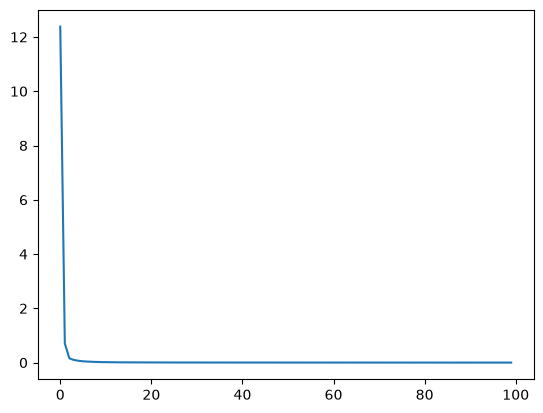

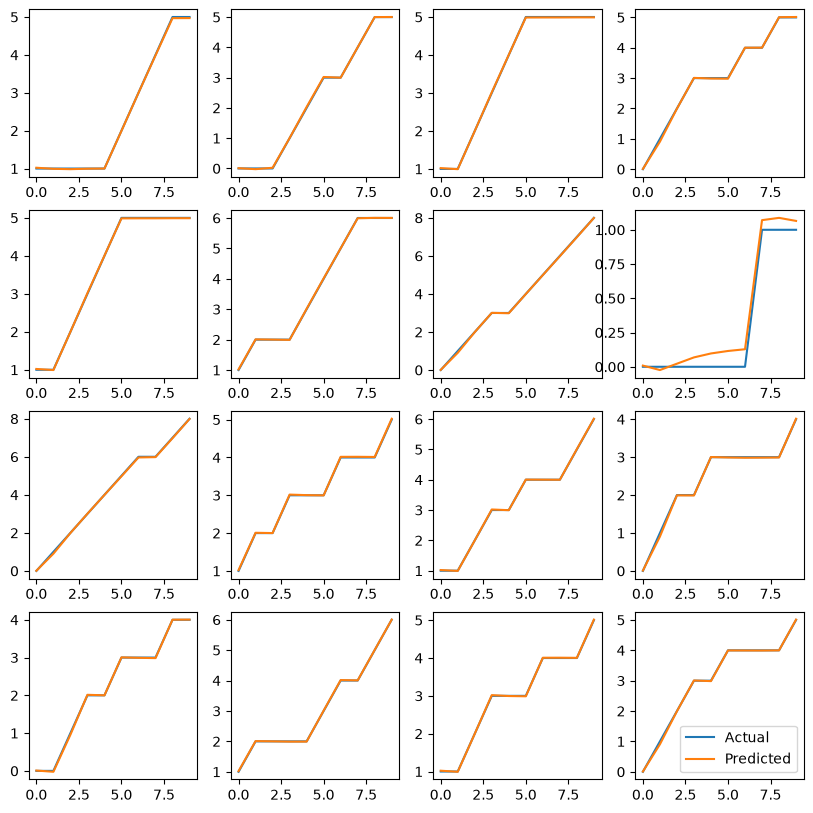

In [60]:
# Baseline
model = LSTMModel().to(DEVICE)

train(model, dl_train, 100)
test_loss = get_test_loss(model, dl_test)
print(f'test loss: {test_loss.item()}')
pretty_eval(model, SumDataset)


100%|██████████| 100/100 [03:07<00:00,  1.88s/it, avg_loss=0.00112]


test loss: 0.0011405990226194263


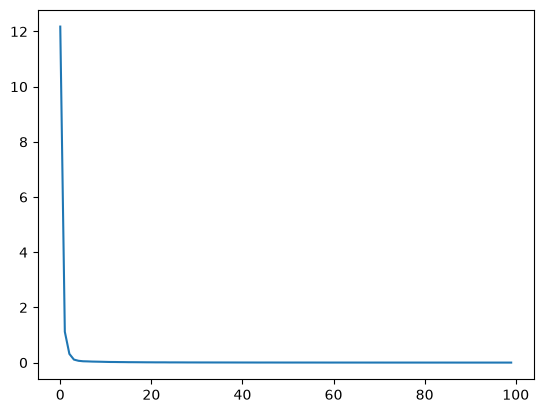

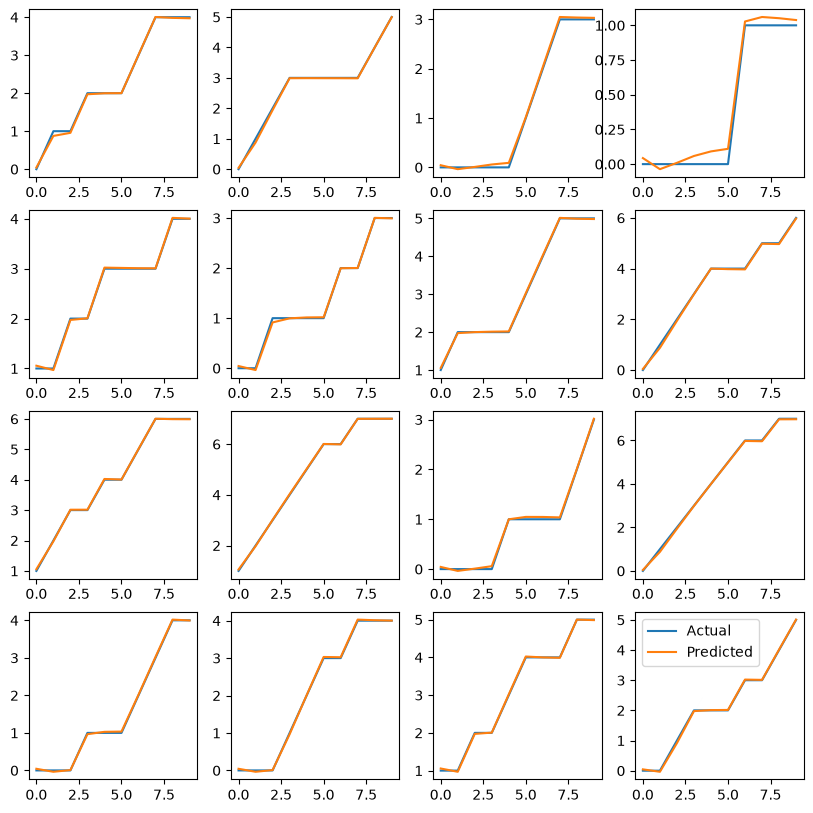

In [18]:
my_model = MyLSTMModel().to(DEVICE)

train(my_model, dl_train, 100)
test_loss = get_test_loss(my_model, dl_test)
print(f'test loss: {test_loss.item()}')
pretty_eval(my_model, SumDataset)

# let's see if we can reconstruct

In [63]:
# get a sample bit of data
x, y = ds_train._generate_one()

In [64]:
model.to('cpu')
test_model = MyLSTMModel()

# before check
y_pred_before = test_model.forward(x).detach().squeeze()
y_pred = model.forward(x).detach().squeeze()

In [69]:
with torch.no_grad():
    # copy lstm weights
    # first, extract
    # order is i -> f -> c (g) -> o
    w_i, w_f, w_c, w_o = model.lstm.weight_ih_l0.mT.chunk(4, 1) # need to T
    u_i, u_f, u_c, u_o = model.lstm.weight_hh_l0.mT.chunk(4, 1)
    
    # i think we sum
    bias = (model.lstm.bias_ih_l0 + model.lstm.bias_hh_l0).unsqueeze(0)
    b_i, b_f, b_c, b_o = bias.chunk(4, 1)
    # bi_i, bi_f, bi_g, bi_o = model.lstm.bias_ih_l0.chunk(4)
    # bh_i, bh_f, bh_g, bh_o = model.lstm.bias_hh_l0.chunk(4)
    
    # let's do this the ugly way
    test_model.lstm.w_f.copy_(w_f)
    test_model.lstm.u_f.copy_(u_f)
    test_model.lstm.b_f.copy_(b_f)
    test_model.lstm.w_i.copy_(w_i)
    test_model.lstm.u_i.copy_(u_i)
    test_model.lstm.b_i.copy_(b_i)
    test_model.lstm.w_o.copy_(w_o)
    test_model.lstm.u_o.copy_(u_o)
    test_model.lstm.b_o.copy_(b_o)
    test_model.lstm.w_c.copy_(w_c)
    test_model.lstm.u_c.copy_(u_c)
    test_model.lstm.b_c.copy_(b_c)

    # copy linear
    test_model.fc.weight.copy_(model.fc.weight)
    test_model.fc.bias.copy_(model.fc.bias)


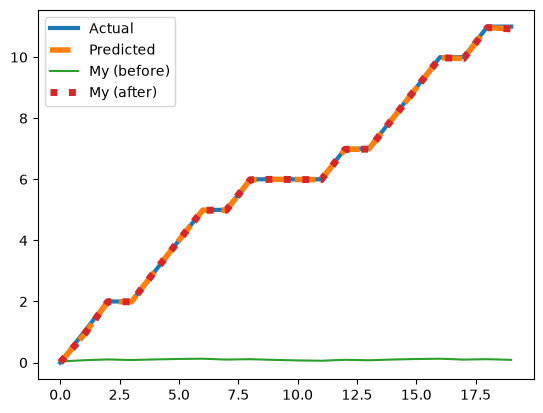

In [83]:
# visual check

y_pred_after = test_model.forward(x).detach().squeeze()

plt.plot(y, label='Actual', linewidth=3)

plt.plot(y_pred, label='Predicted', linestyle='--', linewidth=4)
plt.plot(y_pred_before, label='My (before)')
plt.plot(y_pred_after, label='My (after)', linestyle='dotted', linewidth=5)

plt.legend()

In [71]:
# numerical check
torch.allclose(y_pred, y_pred_after)

True